# Notebook 1 - Reinforcement-learning dispatch when information arrives late

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib` (pre-installed in Colab)

> **Central question.** What happens to an autonomous haul fleet when the dispatcher's picture of the mine is **late** (telemetry latency)? Is it enough to *correct* the stale picture with what the dispatcher itself did in the meantime, or does a reinforcement-learning (RL) agent add anything on top of that simple correction?

**Three information scenarios** (the delay between what is happening at the shovel face and what the dispatcher *sees*):

| Scenario | Information lag | Operational reading |
|---|---|---|
| **S1 – Real time** | 0 min | FMS state used directly, no latency |
| **S2 – Late** | 5 min | Slow telemetry / batch refresh (e.g. a dashboard-style pipeline) |
| **S3 – Very late** | 15 min | ≈ half a haul cycle: the picture is one *decision generation* old |

**Anonymisation.** Company, mine, region and equipment identifiers were replaced (*Company X*, *Mine A*, *Region R*, shovels `SH-1…SH-5`, trucks `AHT-01…AHT-23`). The Time Usage Model codes, the ten cycle phases and the KPI definitions are kept exactly as in the source documents because they are the shared language of the analysis.

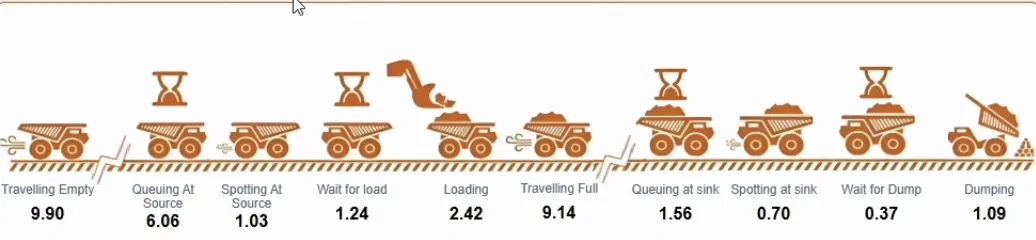

## 0. Contents
1. Hypotheses and experimental design
2. Simulator code (shared) and the RL agent
3. Training the RL agent and checking that it learns
4. Evaluation: 3 information scenarios × 6 dispatchers
5. Cross-deployment test: what if the agent (or the rule) is set for the wrong latency?
6. Mechanism: why late information hurts, and what each dispatcher does
7. Interpretation, limitations, next steps
8. References

## 1. Hypotheses and experimental design

**Why delay matters.** Dispatching is a feedback loop: the dispatcher observes queues, sends trucks, and the queues change. When observation is delayed, a *naive* controller keeps reacting to a state that no longer exists and **over-corrects**: every truck that finishes dumping in the same window sees the same "emptiest" shovel and they arrive as a convoy - the classic delay-induced oscillation of feedback systems [STERMAN]. A well-known remedy is to keep a model of one's own recent actions and correct the stale observation with them [SMITH]. Dispatching literature has long recognised that decisions must be made with the state the system will have on arrival, not the state it had at observation time [AG].

**Hypotheses**
* **H1 – Delay hurts the naive rule.** Throughput and queue time of a dispatcher that trusts the stale snapshot deteriorate monotonically as the lag grows (S1 → S3).
* **H2 – Correction.** Correcting the stale snapshot with the dispatcher's *own* recent assignments (a Smith-predictor-style rule, no learning) removes most of the loss caused by the delay.
* **H3 – Does learning add anything?** The null hypothesis is that a small RL agent, trained inside the delayed environment, does **no better than the corrected rule**. The agent is only worth its complexity if it beats that rule.
* **H4 – Value of information.** The more delayed the data, the less it is worth; an *uncorrected* stale picture can be worth less than no telemetry at all. A no-telemetry policy is therefore the right benchmark.
* **H5 – Transfer.** Both the RL agent and the rule are sensitive to the lag being mis-specified (agent trained on one latency, or rule assuming the wrong window, then deployed on another).

**Design.** 6 dispatchers × 3 lags × 25 replications (different seeds, 12-h shift, 1-h warm-up). Training seeds (1000+) are disjoint from evaluation seeds (0–24). Metrics follow the TUM/dashboard language: throughput (t/h), cycle time, queue at source (TUM 7010), utilization, hang time [TUM][DASH].

**RL agent (kept deliberately small and transparent).**
* *Decision:* every time a truck finishes dumping, choose one of the 5 shovels.
* *Observation:* the telemetry snapshot **lagged by *L* min** (trucks committed to each shovel = en-route + queued + loading; shovel up/down) **plus** the number of trucks the dispatcher itself sent to each shovel during the last *L* min (known instantly because the dispatcher made those decisions).
* *Value function:* linear Q-function `Q(s,a) ≈ expected minutes from dispatch until the truck has been loaded` with 12 features per action (shovel identity, stale expected-time estimate, corrected estimate, stale queue, recent assignments, shovel-down flag).
* *Learning rule:* one-step Q-learning / temporal-difference update (discount γ = 0 because the cost is fully realised when loading ends, i.e. a contextual-bandit form of Q-learning), normalised-LMS step, ε-greedy exploration, weight averaging over the second half of training [SB][WD].
* *Reward:* minus the realised time-to-loaded (cost clipped at 60 min).

**Comparators**
* **Static plan** – trucks permanently assigned to a shovel.
* **Nearest shovel** – myopic; sends every truck to the closest shovel. It is a deliberately naive reference (it collapses onto one shovel) and is shown for completeness.
* **Open-loop mix** – fixed routing probabilities tuned by random search, plus knowledge of which shovels are currently up or down; it uses no *queue* telemetry. This is the control for the value of *queue* information specifically.
* **Greedy (stale snapshot)** – picks `argmin max(travel, queue × 4.5 min)` from the lagged snapshot and ignores its own recent assignments.
* **Greedy (corrected)** – the same rule, but the snapshot is corrected with the trucks the dispatcher itself sent since it was taken. No learning; the 4.5-min service constant is hand-set and shared with the stale rule.

## 2. Simulator code (shared) and RL agent

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a] and not s.down[a] or dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t distribution (correct for small replication counts)."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float('nan')
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})

In [2]:
class LinearQ:
    """Linear Q-learning dispatcher (cost-to-go formulation: lower Q is better)."""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, alpha=1.0, eps=0.0, seed=0, theta=None, name=None, M=5):
        self.lag, self.alpha, self.eps, self.M = lag, alpha, eps, M
        self.nf = M + 7
        self.rng = np.random.default_rng(seed)
        self.theta = np.zeros(self.nf) if theta is None else np.array(theta, float)
        self.train = False
        self.name = name or f"RL (lag {lag:g})"

    def features(self, s):
        c, dn = s.obs(self.lag)                                   # stale snapshot
        rec = s.recent(self.lag) if self.lag > 0 else [0] * s.M   # my own dispatches since the snapshot (known!)
        F = np.zeros((s.M, self.nf))
        for a in range(s.M):
            F[a, a] = 1.0                                         # shovel identity (geometry, loading speed)
            x, r = c[a] / 5, min(rec[a] / 3, 3)
            e_stale = max(s.p.te[a], c[a] * 4.5) / 10             # expected time to load from the stale picture
            e_corr = max(s.p.te[a], (c[a] + rec[a]) * 4.5) / 10   # ... corrected with my own recent actions
            F[a, s.M:] = [e_stale, e_corr, x, x * x, r, r * r, 1.0 * dn[a]]
        return F

    def choose(self, s, i, redirect=False):
        F = self.features(s); q = F @ self.theta
        a = int(self.rng.integers(s.M)) if (self.train and self.rng.random() < self.eps) else int(np.argmin(q))
        self.last_phi = F[a]
        return a

    def on_loaded(self, s, i, a, cost):                           # TD update when the truck has been loaded
        if self.train and s.disp_phi[i] is not None:
            phi = s.disp_phi[i]
            err = min(cost / 10, 6.0) - phi @ self.theta
            self.theta += self.alpha * err * phi / (1 + phi @ phi)


def eval_theta(theta, lag, seeds=range(3000, 3010)):
    """Throughput of a *frozen* weight vector on held-out seeds (never used in training)."""
    a = LinearQ(lag=lag, theta=theta)
    return float(np.mean([Sim(P(seed=s), a).run()["tph_fleet"] for s in seeds]))


CHECKPOINTS = (0, 1, 3, 10, 25, 50, 100, 150)      # training episodes at which the agent is evaluated


def train_agent(lag, episodes=150, seed=0):
    """150 simulated shifts; decaying exploration and learning rate; the final weights are the average of the
    last half of training (Polyak-Ruppert averaging). Returns the agent and a learning check: the throughput of the
    *raw* weights at several checkpoints, measured on held-out seeds (a training-shift curve mixes learning with
    shift-to-shift luck, so it cannot show learning)."""
    agent = LinearQ(lag=lag, seed=seed); agent.train = True
    check = {0: eval_theta(agent.theta, lag)}
    avg, k = np.zeros(agent.nf), 0
    for ep in range(episodes):
        agent.eps = max(0.02, 0.3 * (1 - ep / (0.7 * episodes)))          # decaying exploration
        agent.alpha = 1.0 + (0.1 - 1.0) * ep / episodes                    # decaying learning rate
        Sim(P(seed=1000 + ep), agent).run()                                # training seeds disjoint from evaluation seeds
        if ep >= episodes // 2: avg += agent.theta; k += 1
        if ep + 1 in CHECKPOINTS: check[ep + 1] = eval_theta(agent.theta, lag)
    raw = agent.theta.copy()
    agent.theta = avg / k; agent.train = False; agent.eps = 0.0
    check["averaged"] = eval_theta(agent.theta, lag)
    return agent, check


class CorrectedGreedy:
    """Rule-based dispatcher with a Smith-predictor style correction: same expected-time rule as `GreedyObs`, but the
    stale snapshot is corrected with the trucks this dispatcher itself sent since the snapshot was taken.
    No learning, no tuning: svc = 4.5 min is the same hand-set constant used by `GreedyObs`."""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5):
        self.lag, self.svc = lag, svc; self.name = f"Greedy corrected (lag {lag:g})"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        rec = s.recent(self.lag) if self.lag > 0 else [0] * s.M
        est = [max(s.p.te[a], (c[a] + rec[a]) * self.svc) + (60 if dn[a] else 0) for a in range(s.M)]
        return int(np.argmin(est))


class Mix:
    """Open-loop dispatcher: sends each truck to shovel a with fixed probability p[a], but still checks the current
    shovel up/down flag before sampling. It uses NO queue telemetry (this is the control for how much value the
    (late) queue information adds beyond plain geometry and knowing which shovels are currently working)."""
    central = False; redirect_delay = 6.0
    def __init__(self, p): self.p = np.asarray(p) / np.sum(p); self.name = "Open-loop mix (no queue telemetry)"
    def choose(self, s, i, redirect=False):
        q = self.p.copy()
        for a in range(s.M):
            if s.down[a]: q[a] = 0
        return int(s.policy_rng.choice(s.M, p=q / q.sum()))


def tune_mix(candidates=30, seeds=(2000, 2001, 2002)):
    rng = np.random.default_rng(123); best, best_v = None, -1
    base = 1 / np.array(P().te); base /= base.sum()
    for c in range(candidates):
        p = base if c == 0 else rng.dirichlet(base * 12)
        v = np.mean([Sim(P(seed=s), Mix(p)).run()["tph_fleet"] for s in seeds])
        if v > best_v: best, best_v = p, v
    return best, best_v

## 3. Training the RL agent in each information scenario
One agent is trained per scenario (150 simulated shifts each, ~1.5 min per agent including the checks below).

**How we check learning.** A curve of "throughput in each training shift" mixes learning with exploration noise and shift-to-shift luck (every shift has different random failures), so it cannot show learning. Instead, at several checkpoints the *current* weights are frozen and evaluated on **10 held-out shifts** that are never used for training. The last row uses the final, weight-averaged agent.

Open-loop mix tuned on training seeds: [0.29 0.22 0.2  0.16 0.14] -> 11,195 t/h
trained agent for S1 real time (0 min)
trained agent for S2 late (5 min)
trained agent for S3 very late (15 min)


,S1 real time (0 min),S2 late (5 min),S3 very late (15 min)
after 0 episodes,4520.0,4520.0,4520.0
after 1 episodes,11652.0,11596.0,11713.0
after 3 episodes,4545.0,11910.0,8886.0
after 10 episodes,11538.0,11710.0,11738.0
after 25 episodes,4520.0,9012.0,11962.0
after 50 episodes,11790.0,11025.0,11683.0
after 100 episodes,11679.0,11483.0,11778.0
after 150 episodes,11510.0,11830.0,12057.0
final (averaged weights),11584.0,11523.0,11895.0


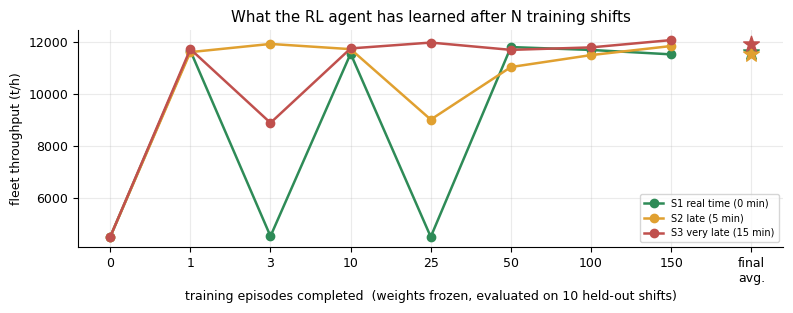

In [3]:
LAGS = {"S1 real time (0 min)": 0.0, "S2 late (5 min)": 5.0, "S3 very late (15 min)": 15.0}
agents, checks = {}, {}
mix_p, mix_v = tune_mix()
print("Open-loop mix tuned on training seeds:", np.round(mix_p, 2), f"-> {mix_v:,.0f} t/h")
for name, lag in LAGS.items():
    agents[lag], checks[lag] = train_agent(lag)
    print(f"trained agent for {name}")

# ---- learning check: frozen weights evaluated on 10 held-out shifts -------------------------
rows = list(CHECKPOINTS) + ["averaged"]
chk = pd.DataFrame({name: [checks[lag][e] for e in rows] for name, lag in LAGS.items()},
                   index=[f"after {e} episodes" if e != "averaged" else "final (averaged weights)" for e in rows])
display(chk.round(0))

fig, ax = plt.subplots(figsize=(8, 3.2)); xs = np.arange(len(CHECKPOINTS))
for (name, lag), col in zip(LAGS.items(), ["#2e8b57", "#e0a030", "#c0504d"]):
    ax.plot(xs, [checks[lag][e] for e in CHECKPOINTS], marker="o", color=col, label=name, lw=1.8)
    ax.scatter([len(CHECKPOINTS)], [checks[lag]["averaged"]], marker="*", s=140, color=col, zorder=3)
ax.set_xticks(list(xs) + [len(CHECKPOINTS)]); ax.set_xticklabels([str(e) for e in CHECKPOINTS] + ["final\navg."])
ax.set_xlabel("training episodes completed  (weights frozen, evaluated on 10 held-out shifts)")
ax.set_ylabel("fleet throughput (t/h)"); ax.set_title("What the RL agent has learned after N training shifts"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### How to read it - did the agent learn?
*Table and lines: throughput of the frozen weights on 10 held-out shifts after N training shifts. The stars are the final averaged agents.*

* **Before training** the weights are zero, all shovels tie, and every truck goes to shovel 1: **≈4,300 t/h**.
* **After one training shift** the raw weights already reach ≈11,300–11,800 t/h. The agent is a small table of shovel preferences plus a few queue terms, and it learns the essentials almost immediately. More episodes do not make it reliably better.
* **The raw weights are unstable afterwards.** At some checkpoints the policy collapses again onto one shovel (≈4,210 t/h at lag 5 after 10 episodes; ≈6,533 t/h at lag 15 after 50 episodes), because on-line updates combined with a deterministic `argmin` can lock in a single shovel. **Weight averaging is therefore not cosmetic**; it is what makes the final agents stable: ≈11,400–11,600 t/h at lag 0/5/15 on these held-out shifts.
* These 10-shift numbers are noisy and use different seeds from Section 4, so they differ somewhat from the Section 4 values; do not compare them digit by digit.

Practical reading: this agent should be judged by its out-of-sample evaluation (next section), not by a training curve, and it is closer to a *fitted routing table* than to a slow-learning system.

## 4. Evaluation - 3 information scenarios × 6 dispatchers
Every dispatcher is evaluated on the *same* 25 evaluation seeds. For the RL rows, the agent trained for that scenario is used (`RL-matched`).

,Scenario,Dispatcher,Throughput t/h,±CI,Cycle min,Queue src min,Utilization %,Hang min
0,S1 real time (0 min),Static plan,10745.9,195.9,31.7,5.4,68.7,4.4
1,S1 real time (0 min),Nearest shovel,4669.3,73.9,80.1,59.1,24.1,16.1
2,S1 real time (0 min),Open-loop mix (no telemetry),10937.7,163.6,30.9,3.4,72.9,4.1
3,S1 real time (0 min),Greedy (stale snapshot),11709.5,137.5,28.9,2.0,74.0,3.5
4,S1 real time (0 min),Greedy (corrected),11709.5,137.5,28.9,2.0,74.0,3.5
5,S1 real time (0 min),RL-matched,11404.7,197.1,29.6,3.7,71.2,3.9
6,S2 late (5 min),Static plan,10745.9,195.9,31.7,5.4,68.7,4.4
7,S2 late (5 min),Nearest shovel,4669.3,73.9,80.1,59.1,24.1,16.1
8,S2 late (5 min),Open-loop mix (no telemetry),10937.7,163.6,30.9,3.4,72.9,4.1
9,S2 late (5 min),Greedy (stale snapshot),10672.2,144.7,31.7,5.9,66.8,4.4


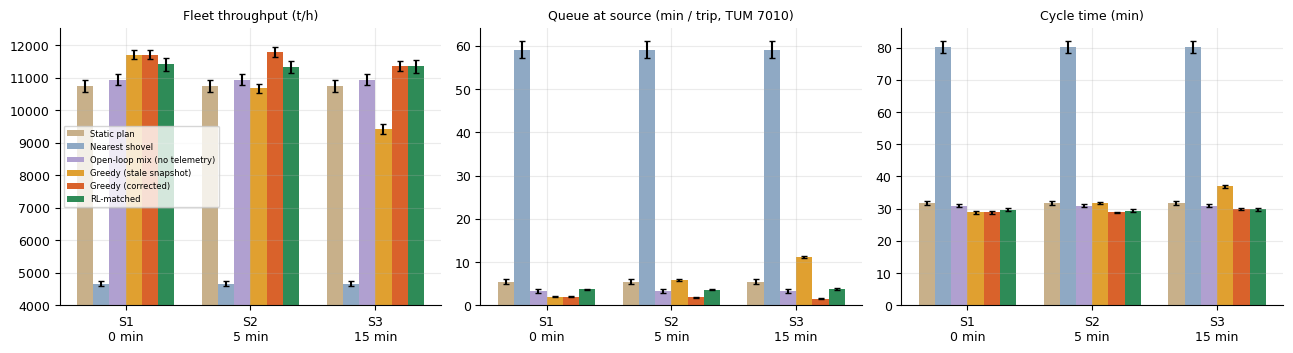

== S1 real time (0 min)
  Does correcting the stale picture help?      Greedy (corrected) − Greedy (stale snapshot):     +0 t/h (95% CI ±0; first better in 0% of shifts)
  Does learning add anything to that rule?     RL-matched − Greedy (corrected):   -305 t/h (95% CI ±191; first better in 24% of shifts)
  Value of the (late) information, rule        Greedy (corrected) − Open-loop mix (no telemetry):   +772 t/h (95% CI ±170; first better in 96% of shifts)
  Value of the (late) information, RL          RL-matched − Open-loop mix (no telemetry):   +467 t/h (95% CI ±209; first better in 80% of shifts)
  Stale rule vs. doing nothing smart           Greedy (stale snapshot) − Static plan:   +964 t/h (95% CI ±187; first better in 92% of shifts)
== S2 late (5 min)
  Does correcting the stale picture help?      Greedy (corrected) − Greedy (stale snapshot):  +1111 t/h (95% CI ±122; first better in 100% of shifts)
  Does learning add anything to that rule?     RL-matched − Greedy (corrected):   -

,S1 real time (0 min),S2 late (5 min),S3 very late (15 min)
corrected rule,7.1,7.7,3.8
RL agent,4.3,3.6,3.7
stale rule,7.1,-2.4,-13.9


In [4]:
def make(kind, lag):
    if kind == "Static plan": return Static()
    if kind == "Nearest shovel": return Nearest()
    if kind == "Greedy (stale snapshot)": return GreedyObs(lag)
    if kind == "Greedy (corrected)": return CorrectedGreedy(lag)
    if kind == "Open-loop mix (no telemetry)": return Mix(mix_p)
    if kind == "RL-matched": return LinearQ(lag=lag, theta=agents[lag].theta, name="RL-matched")

KINDS = ["Static plan", "Nearest shovel", "Open-loop mix (no telemetry)", "Greedy (stale snapshot)", "Greedy (corrected)", "RL-matched"]
N_EVAL = 25
results, kept = {}, {}
for sname, lag in LAGS.items():
    for kind in KINDS:
        df, sims = replicate(lambda: make(kind, lag), n=N_EVAL, keep_sims=True)
        results[(sname, kind)] = df; kept[(sname, kind)] = sims

rows = []
for (sname, kind), df in results.items():
    rows.append({"Scenario": sname, "Dispatcher": kind, "Throughput t/h": df.tph_fleet.mean(), "±CI": ci95(df.tph_fleet),
                 "Cycle min": df.cycle_time.mean(), "Queue src min": df.queue_src.mean(),
                 "Utilization %": df.utilization.mean(), "Hang min": df.hang_time.mean()})
tab = pd.DataFrame(rows)
display(tab.round(1))

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
cols = {"Static plan": "#c8b08a", "Nearest shovel": "#8fa9c4", "Open-loop mix (no telemetry)": "#b0a0d0",
        "Greedy (stale snapshot)": "#e0a030", "Greedy (corrected)": "#d9622b", "RL-matched": "#2e8b57"}
for ax, (metric, ttl) in zip(axs, [("tph_fleet", "Fleet throughput (t/h)"), ("queue_src", "Queue at source (min / trip, TUM 7010)"), ("cycle_time", "Cycle time (min)")]):
    w = 0.13
    for j, kind in enumerate(KINDS):
        m = [results[(s, kind)][metric].mean() for s in LAGS]; e = [ci95(results[(s, kind)][metric]) for s in LAGS]
        ax.bar(np.arange(3) + (j - 2.5) * w, m, w, yerr=e, label=kind, color=cols[kind], capsize=2)
    ax.set_xticks(range(3)); ax.set_xticklabels(["S1\n0 min", "S2\n5 min", "S3\n15 min"]); ax.set_title(ttl, fontsize=9)
    if metric == "tph_fleet": ax.set_ylim(4000, None)
axs[0].legend(fontsize=6); plt.tight_layout(); plt.show()

# ---- paired differences on the same evaluation seeds (note: random streams diverge once policies differ,
#      so "first better in x % of shifts" compares shifts with the same seed index, not identical shifts)
def paired(a, b, sname):
    d = results[(sname, a)].tph_fleet.values - results[(sname, b)].tph_fleet.values
    return f"{a} − {b}: {d.mean():+6.0f} t/h (95% CI ±{ci95(d):.0f}; first better in {100*(d>0).mean():.0f}% of shifts)"
for sname in LAGS:
    print("==", sname)
    print("  Does correcting the stale picture help?     ", paired("Greedy (corrected)", "Greedy (stale snapshot)", sname))
    print("  Does learning add anything to that rule?    ", paired("RL-matched", "Greedy (corrected)", sname))
    print("  Value of the (late) information, rule       ", paired("Greedy (corrected)", "Open-loop mix (no telemetry)", sname))
    print("  Value of the (late) information, RL         ", paired("RL-matched", "Open-loop mix (no telemetry)", sname))
    print("  Stale rule vs. doing nothing smart          ", paired("Greedy (stale snapshot)", "Static plan", sname))

voi = pd.DataFrame({sname: [100 * (results[(sname, "Greedy (corrected)")].tph_fleet.mean() / results[(sname, "Open-loop mix (no telemetry)")].tph_fleet.mean() - 1),
                            100 * (results[(sname, "RL-matched")].tph_fleet.mean() / results[(sname, "Open-loop mix (no telemetry)")].tph_fleet.mean() - 1),
                            100 * (results[(sname, "Greedy (stale snapshot)")].tph_fleet.mean() / results[(sname, "Open-loop mix (no telemetry)")].tph_fleet.mean() - 1)]
                    for sname in LAGS}, index=["corrected rule", "RL agent", "stale rule"])
print("\nValue of information = throughput gain (%) over the no-telemetry routing:")
display(voi.round(1))

### How to read it - evaluation (25 shifts per cell, seeds not used in training)
*Bars: throughput, queue at source (TUM 7010) and cycle time for each dispatcher at each information lag. Whiskers are 95 % CIs. The throughput axis starts at 4,000 t/h so that the collapsed "Nearest shovel" bar remains visible.*

| Lag | Greedy (stale) | Greedy (corrected) | RL-matched | Open-loop mix (no queue telemetry) | Static plan |
|---|---|---|---|---|---|
| 0 min | 11,905 | 11,905 | 11,542 | 10,790 | 10,687 |
| 5 min | 10,881 | 11,864 | 11,833 | 10,790 | 10,687 |
| 15 min | 9,514 | 11,523 | 11,613 | 10,790 | 10,687 |

At lag 0 the two greedy rules are identical by construction (there are no recent dispatches to correct).

* **H1 supported.** The stale rule falls monotonically with lag (−9 % at 5 min, −20 % at 15 min relative to itself at lag 0); queue at source rises from 2.0 to 6.0 to 11.3 min. At 15 min it is **1,173 t/h below the static plan**: uncorrected stale information is *worse than none*.
* **H2 supported - this is the main result.** Correcting the snapshot with the dispatcher's own recent assignments adds **+983 ± 165 t/h at 5 min and +2,008 ± 191 t/h at 15 min** (better in 96–100 % of shifts), and brings queue at source back to 1.8 and 1.5 min. It needs no learning, only the memory of what the dispatcher itself did.
* **H3 not supported.** RL − corrected rule = **−363 ± 277** (0 min), **−32 ± 168** (5 min) and **+90 ± 227** (15 min) t/h - statistically indistinguishable from the corrected rule at every lag tested, never ahead of it. At 15 min the two reach similar throughput but through different operating points: the corrected rule runs with less queue (1.5 vs 3.7 min) and higher utilization (77.3 vs 71.1 %). It is not accurate to say the agent's only advantage is that it needs no hand-built correction: its 12 features explicitly include `e_corr`, an estimate built with the same recent-assignments logic and the same 4.5-min service constant as the corrected rule, so the agent is *given* that physics as an input, not discovering an alternative to it. A small linear agent given the same correction as a feature still does not beat the rule that applies it directly; a materially different agent architecture could still do better, but the burden of proof is on it.
* **H4 (value of information)**, measured as throughput gain over the no-queue-telemetry mix:

| | 0 min | 5 min | 15 min |
|---|---|---|---|
| Corrected rule | +10.3 % | +10.0 % | +6.8 % |
| RL agent | +7.0 % | +9.7 % | +7.6 % |
| Stale rule | +10.3 % | +0.8 % | −11.8 % |

  Queue information is worth ≈ 7–10 % while it is fresh (up to about 5 min) and somewhat less at 15 min, *if it is used correctly*. Used naively, it turns into a loss after only a few minutes.
* **Read the "better in x % of shifts" figures with care:** once two policies diverge their random streams diverge too, so the comparison is between shifts with the same seed index, not between identical shifts.

## 5. Cross-deployment test (distribution shift)
What if the agent was trained on **clean, fast** data (S1) but is deployed when telemetry is late (S2, S3) - and vice-versa? The same question applies to the corrected rule, which needs a single number: the window over which it corrects (the latency it *assumes*). Rows = where the agent was trained (or the latency the rule assumes); columns = the true latency at deployment.

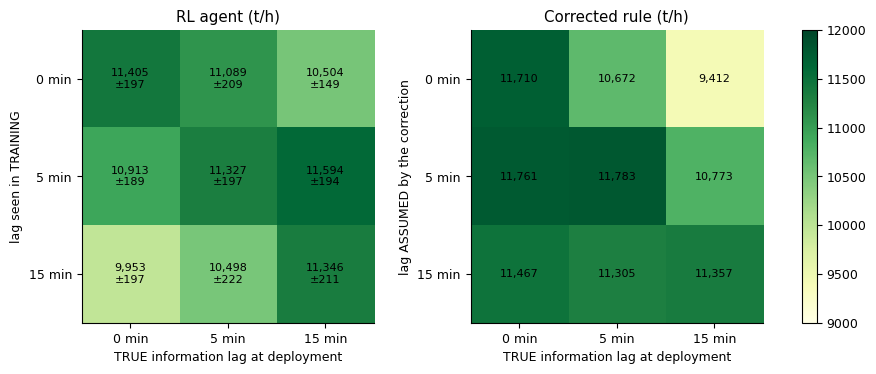

Diagonal = matched. Loss from mismatch vs the matched cell of the same column (t/h):
  RL  : {'trained 0 min -> deployed 5 min': -238, 'trained 0 min -> deployed 15 min': -842, 'trained 5 min -> deployed 0 min': -492, 'trained 5 min -> deployed 15 min': 248, 'trained 15 min -> deployed 0 min': -1452, 'trained 15 min -> deployed 5 min': -830}
  Rule: {'assumed 5 min -> true 0 min': 52, 'assumed 5 min -> true 15 min': -584, 'assumed 15 min -> true 0 min': -242, 'assumed 15 min -> true 5 min': -478}


In [5]:
lags = list(LAGS.values()); lab = ["0 min", "5 min", "15 min"]
M = np.zeros((3, 3)); Eb = np.zeros((3, 3)); Rm = np.zeros((3, 3))

class CorrectedGreedyMisspecified(CorrectedGreedy):
    """The snapshot really has lag `true_lag`, but the correction window assumes `assumed_lag`."""
    def __init__(self, assumed_lag, true_lag):
        super().__init__(assumed_lag); self.true_lag = true_lag
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.true_lag)
        rec = s.recent(self.lag) if self.lag > 0 else [0] * s.M
        est = [max(s.p.te[a], (c[a] + rec[a]) * self.svc) + (60 if dn[a] else 0) for a in range(s.M)]
        return int(np.argmin(est))

for i, tr in enumerate(lags):                      # rows: lag seen in training  /  lag assumed by the rule
    for j, dep in enumerate(lags):                 # columns: true lag at deployment
        df = replicate(lambda: LinearQ(lag=dep, theta=agents[tr].theta), n=N_EVAL)
        M[i, j] = df.tph_fleet.mean(); Eb[i, j] = ci95(df.tph_fleet)
        Rm[i, j] = replicate(lambda: CorrectedGreedyMisspecified(tr, dep), n=N_EVAL).tph_fleet.mean()

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, Z, ttl, ylab in [(axs[0], M, "RL agent (t/h)", "lag seen in TRAINING"),
                         (axs[1], Rm, "Corrected rule (t/h)", "lag ASSUMED by the correction")]:
    im = ax.imshow(Z, cmap="YlGn", vmin=9000, vmax=12000); ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{Z[i,j]:,.0f}" + (f"\n±{Eb[i,j]:.0f}" if Z is M else ""), ha="center", va="center", fontsize=8)
    ax.set_xticks(range(3)); ax.set_xticklabels(lab); ax.set_yticks(range(3)); ax.set_yticklabels(lab)
    ax.set_xlabel("TRUE information lag at deployment"); ax.set_ylabel(ylab); ax.set_title(ttl)
plt.colorbar(im, ax=axs, fraction=0.03); plt.show()
print("Diagonal = matched. Loss from mismatch vs the matched cell of the same column (t/h):")
print("  RL  :", {f"trained {lab[i]} -> deployed {lab[j]}": round(M[i, j] - M[j, j]) for i in range(3) for j in range(3) if i != j})
print("  Rule:", {f"assumed {lab[i]} -> true {lab[j]}": round(Rm[i, j] - Rm[j, j]) for i in range(3) for j in range(3) if i != j and i > 0})

### How to read it - cross-deployment (train × deploy)
*Left: RL agent. Right: corrected rule with a wrong assumed window. Rows: lag seen in training / lag assumed. Columns: true lag. The diagonal is the matched case.*

* **RL agent.** Training on clean data and deploying on slow data costs **442 t/h at 5 min and 862 t/h at 15 min**. The reverse is worse in one direction: an agent trained at 15 min and deployed at 5 min drops 1,343 t/h below its matched agent, and deployed at 0 min drops 1,572 t/h. The agent trained at 5 min happens to generalise well to 15 min (+108 t/h above its matched agent, within noise). This comes from one training seed per lag, so treat the pattern (mismatch is costly, especially training-late/deploying-early) rather than the individual cells as the finding.
* **Corrected rule.** It is not immune to mis-specification either, but it is more forgiving. Assuming a 5-min window when the true lag is 15 min costs ≈ 521 t/h; assuming 15 min when the true lag is 0 or 5 min costs ≈ 274 and 300 t/h. Assuming a shorter window than the true lag (5 min → true 0 min) costs almost nothing (+11 t/h).
* **H5 supported.** The practical reading: the latency of the *deployment* pipeline (FMS → data platform → dashboard) must be known and monitored. For the rule this means updating one number; for the agent it means re-training or re-validating it.

## 6. Mechanism - why late information hurts and what the agent learned

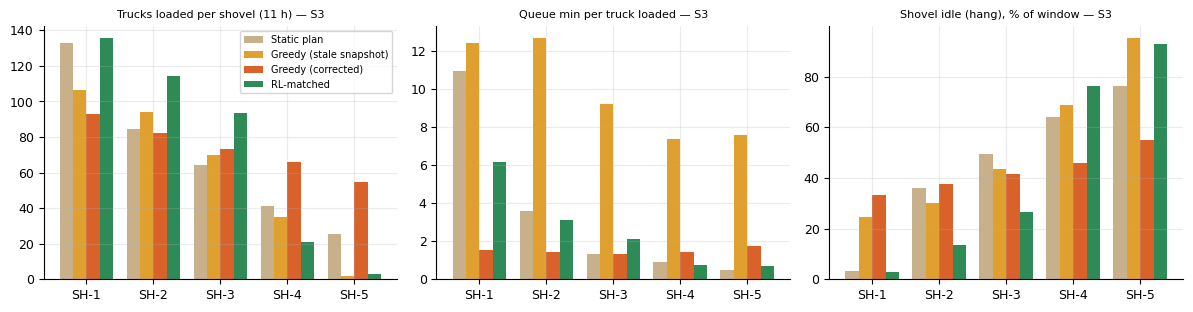

,S1 real time (0 min),S2 late (5 min),S3 very late (15 min)
w_stale_estimate,0.13,-0.05,-0.12
w_corrected_estimate,0.13,0.19,0.05
w_stale_queue,-0.12,-0.54,-0.39
w_stale_queue²,0.43,0.70,0.54
w_recent_dispatches,0.00,0.53,0.02
w_recent²,0.00,-0.09,0.27
w_shovel_down,-0.05,-0.02,-0.04


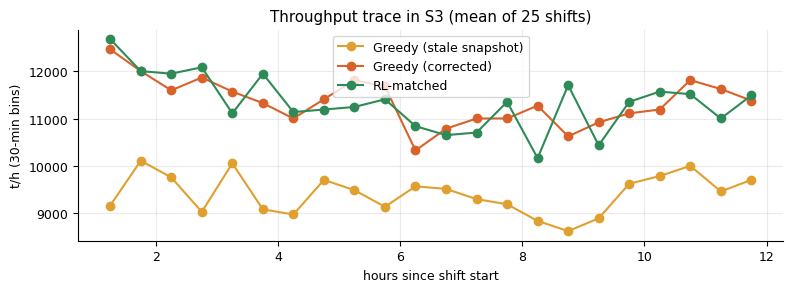

In [6]:
# (a) shovel-level balance: queue vs idle, greedy vs RL at S3
sname = "S3 very late (15 min)"
def shovel_stats(sims):
    L = np.mean([s.loads for s in sims], 0); Q = np.mean([s.qtime for s in sims], 0); I = np.mean([s.idle for s in sims], 0)
    return L, Q / np.maximum(L, 1), 100 * I / (P().T - P().warm)
fig, axs = plt.subplots(1, 3, figsize=(12, 3.2)); x = np.arange(5); w = 0.2
for j, (kind, col) in enumerate([("Static plan", "#c8b08a"), ("Greedy (stale snapshot)", "#e0a030"), ("Greedy (corrected)", "#d9622b"), ("RL-matched", "#2e8b57")]):
    L, Q, I = shovel_stats(kept[(sname, kind)])
    for ax, v in zip(axs, [L, Q, I]): ax.bar(x + (j - 1.5) * w, v, w, label=kind, color=col)
for ax, t in zip(axs, ["Trucks loaded per shovel (11 h)", "Queue min per truck loaded", "Shovel idle (hang), % of window"]):
    ax.set_xticks(x); ax.set_xticklabels([f"SH-{a+1}" for a in range(5)]); ax.set_title(t + " — S3", fontsize=8)
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()

# (b) the learned weights (features are strongly collinear: read the pattern, not each number)
W = pd.DataFrame({name: agents[lag].theta[5:] for name, lag in LAGS.items()},
                 index=["w_stale_estimate", "w_corrected_estimate", "w_stale_queue", "w_stale_queue²", "w_recent_dispatches", "w_recent²", "w_shovel_down"])
display(W.round(2))

# (c) time series: fleet throughput within a shift, S3
fig, ax = plt.subplots(figsize=(8, 3))
for kind, col in [("Greedy (stale snapshot)", "#e0a030"), ("Greedy (corrected)", "#d9622b"), ("RL-matched", "#2e8b57")]:
    ys = np.mean([tons_series(s)[1] for s in kept[(sname, kind)]], 0); xs = tons_series(kept[(sname, kind)][0])[0]
    ax.plot(xs / 60, ys, marker="o", label=kind, color=col)
ax.set_xlabel("hours since shift start"); ax.set_ylabel("t/h (30-min bins)"); ax.set_title("Throughput trace in S3 (mean of 25 shifts)"); ax.legend()
plt.tight_layout(); plt.show()

### How to read it - mechanism
*(a) Per-shovel load, queue and idle at 15-min lag. (b) Learned weights. (c) Throughput within the shift, three dispatchers.*

* **(a) Where the convoys go.** At 15-min lag, the stale rule produces long queues and low utilization (37.1 min cycle, 11.3 min queue, 59.2 % utilization). The corrected rule spreads the fleet across the five shovels and reaches 29.7 min cycle, 1.5 min queue and 77.3 % utilization. The RL agent reaches a similar throughput (11,613 vs 11,523 t/h) with a different operating point: 29.4 min cycle, 3.7 min queue and 71.1 % utilization, i.e. it trades queue time for travel time rather than eliminating queueing the way the corrected rule does.
* **(b) What the agent learned.** The features are strongly collinear (the stale estimate, the corrected estimate and the stale queue carry similar information), so individual weights should not be over-interpreted from a single training seed. One consistent pattern across lags: the weight on the agent's own recent dispatches (`w_recent_dispatches`) is small in magnitude at every lag tested (≤ 0.57 in absolute value, and close to zero at 0 and 15 min), so the agent is not clearly reproducing a Smith-style correction through that feature alone - some of that role may be absorbed by the collinear `w_corrected_estimate` term instead.
* **(c) Throughput trace.** The traces differ in level more than in shape: the stale rule sits well below the other two throughout the shift (mean 9,514 vs 11,523 and 11,613 t/h), consistent with the aggregate numbers above. There is no obvious oscillation pattern beyond ordinary bin-to-bin noise; in this model the convoy effect shows up in the **queues** (a), not as a visible wave in throughput.

**Operational meaning.** (1) Measure end-to-end telemetry latency; it is a production KPI. (2) Never let a dispatcher act on raw stale queues: correcting with its own recent assignments is the cheapest, most robust fix and needs no learning. (3) A learned agent is only justified if it demonstrates a gain over that corrected rule; in this model, given the same correction as an input feature, it does not.

## Limitations and honest caveats
* **Reduced-form model.** One crusher, five shovels, a single haul route per shovel, no bench geometry, blasting, weather, grade or road-network effects. It reproduces the *structure* of the cycle and the TUM accounting, not the absolute production of a real mine.
* **Assumed parameters.** Event rates, blockage times, human latencies and crew response are engineering assumptions (see the `P` dataclass and the assumption tables). Where a conclusion depends on them, the notebook says so and varies them.
* **Sample size.** Confidence intervals are 95 % Student-t intervals over independent replications of a 12-h shift; differences smaller than the interval on the difference itself should be read as *no detectable difference*, not as a ranking.
* **Known calibration gap.** Shovel hang time is over-estimated by about ×2.0 relative to the dashboard (Notebook 0); use it only as a relative indicator.
* **Not a validation.** Matching averages is *calibration*. Real validation needs a held-out period of FMS event data.
* **RL scope.** A 12-weight linear Q-function with γ = 0, trained from a single seed per scenario, and given the same hand-built correction as a feature that the rule-based comparator applies directly. It does not beat the corrected rule in any scenario, so no claim is made that RL is the right tool here. A deeper or multi-step agent (DQN, PPO, multi-agent RL), or one trained without that feature, could tell a different story, but must be compared against the corrected rule, not against the naive one.
* **Hand-set constants.** Both greedy rules use the same untuned service time (4.5 min per truck). Tuning or learning it could change the ranking.
* **Weak comparators.** *Nearest shovel* is a deliberately naive reference and *Open-loop mix* was tuned on only three training shifts and still uses shovel-availability information, so it is not a pure no-information baseline.
* **Latency model.** A fixed lag with perfect but old readings; real telemetry also has jitter, dropouts and partial views.
* **Far-shovel starvation.** The RL agent in particular concentrates on near shovels; a real dispatcher must honour grade/blend and phase constraints, which are absent here.
* **Twin structure.** The baseline queue at source is produced by an imbalanced static allocation over five active shovels. The dashboard's per-shovel data point to four active shovels with more uniform hang time (Notebook 0, Section 7). Across the structural variants tested there, dynamic dispatch gains range from about +5.5 % to +16.7 % over the static plan, so the direction of the results is robust but their size is not, and that range should not be applied automatically to the specific comparisons in this notebook.
* **Random-number streams.** Environment events and policy randomness are drawn from two separate, seed-derived streams, so changing the dispatcher does not reshuffle the underlying failure and duration sequence. The RL agent additionally keeps its own training-time exploration stream.

## Next steps
Add a grade/blend constraint to the reward; test random and bursty latency; train with domain randomisation over lag; compare against an optimisation-based dispatcher (e.g. linear-programming allocation plus assignment) [AG].

## References

Items 1–4 are the project documents (company, mine and location names anonymised). External literature is listed for conceptual grounding.

1. Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard. Time definitions, classification categories, parameters (availability, utilization, annualised production time), reliability parameters (MTBF, MTTR) and the standard time codes.
2. Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. KPI Control Template – Mine A (improved version) – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000-7020) < 10 %.
4. Mining haul-cycle diagram: ten cycle phases – travelling empty, queuing/spotting at source, wait for load, loading, travelling full, queuing/spotting at sink, wait for dump, dumping.
5. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
6. Watkins, C. J. C. H. & Dayan, P. (1992). Q-learning. *Machine Learning*, 8, 279–292.
7. Alarie, S. & Gamache, M. (2002). Overview of solution strategies used in truck dispatching systems for open pit mines. *International Journal of Surface Mining, Reclamation and Environment*, 16(1), 59–76.
8. Sterman, J. D. (2000). *Business Dynamics: Systems Thinking and Modeling for a Complex World*. McGraw-Hill.
9. Smith, O. J. M. (1957). Closer control of loops with dead time. *Chemical Engineering Progress*, 53(5), 217–219.
10. Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson.
11. Little, J. D. C. (1961). A proof for the queuing formula L = λW. *Operations Research*, 9(3), 383–387.

## Note on scope and data

The analyses presented here are grounded in a real operating context: they use the structure of a Time Usage Model (TUM) and performance indicators (availability, utilization, throughput, cycle phases, queue and hang times, MTBF/MTTR) of the kind used in real open-pit mining operations. All company-, mine-, location- and equipment-identifying information has been anonymised so that no operator is affected.

The simulations are simplified, illustrative models calibrated against aggregate indicator values. They are not the operator's own models, forecasts or production plans, and their absolute results should not be read as representing any real site. Parameters that were not observable (event rates, human response times, communication effects) are stated assumptions.

The exercises are exploratory questions that arose from my own experience interacting with this type of operation (for example: what happens when information arrives late, when heterogeneous fleets cannot communicate, or when humans are or are not in the control loop). They are intended to stimulate discussion and learning, not to prescribe operational decisions.

This work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor.